In [1]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


In [2]:
df = pd.read_csv('../data/features/features_complete.csv')

features = [

    # --- Title / NLP features ---
    'title_length',
    'title_word_count',
    'uppercase_words',
    'num_emojis',
    'has_emoji',
    'contains_numbers_or_emojis',
    'has_question',
    'is_clickbait',
    'sentiment_polarity',
    'sentiment_subjectivity',

    # ---  content ---
    'top50_pca1',
    'top50_pca2',
    'top50_pca3',

    # --- Time Features ---
    'is_published_weekend',

    # --- Metadata ---
    'category_id',
    'comments_disabled',
    'ratings_disabled',


     'days_until_trending',     
]
X = df[features]
y = np.log1p(df['views'])
print(f"Shape: X={X.shape}, y={y.shape}")

Shape: X=(55886, 18), y=(55886,)


In [3]:
xgb_model = xgb.XGBRegressor(
    random_state=42,
    verbosity=0  # Suppress training output
)
X_train, X_test, y_train, y_test  = train_test_split(X,y,test_size=0.2, random_state=42)


In [4]:

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [5]:
y_pred_xgb = xgb_model.predict(X_test)

In [6]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\nXGBoost Model Performance (LOG SCALE):")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE:  {mae_xgb:.4f}")
print(f"R²:   {r2_xgb:.4f}")



XGBoost Model Performance (LOG SCALE):
RMSE: 1.3848
MAE:  1.0923
R²:   0.3191


In [7]:
print("\n" + "="*60)
print("XGBOOST FEATURE IMPORTANCE")
print("="*60)

# Get feature importance scores
importance_scores = xgb_model.feature_importances_

# Create list of (feature, importance) tuples and sort
feature_importance = list(zip(features, importance_scores))
feature_importance.sort(key=lambda x: x[1], reverse=True)

print("\nTop Features (sorted by importance):")
for i, (feature, importance) in enumerate(feature_importance, 1):
    bar = '█' * int(importance * 100)
    print(f"{i:2d}. {feature:<30} {importance:>6.4f} {bar}")


XGBOOST FEATURE IMPORTANCE

Top Features (sorted by importance):
 1. top50_pca2                     0.2829 ████████████████████████████
 2. sentiment_subjectivity         0.0775 ███████
 3. comments_disabled              0.0701 ███████
 4. ratings_disabled               0.0682 ██████
 5. days_until_trending            0.0642 ██████
 6. num_emojis                     0.0641 ██████
 7. uppercase_words                0.0624 ██████
 8. category_id                    0.0599 █████
 9. top50_pca3                     0.0380 ███
10. contains_numbers_or_emojis     0.0354 ███
11. top50_pca1                     0.0343 ███
12. title_length                   0.0291 ██
13. has_question                   0.0274 ██
14. title_word_count               0.0256 ██
15. is_clickbait                   0.0230 ██
16. sentiment_polarity             0.0216 ██
17. is_published_weekend           0.0163 █
18. has_emoji                      0.0000 


In [8]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distributions for RandomizedSearchCV
param_distributions = {
    'n_estimators': [100, 200, 300, 500],           # Number of trees
    'max_depth': [3, 5, 7, 9, 12],                  # Tree depth
    'learning_rate': [0.01, 0.05, 0.1, 0.2],        # Step size
    'subsample': [0.6, 0.8, 1.0],                   # Sample ratio per tree
    'colsample_bytree': [0.6, 0.8, 1.0],            # Feature ratio per tree
    'min_child_weight': [1, 3, 5, 7],               # Minimum samples in leaf
    'gamma': [0, 0.1, 0.2, 0.5],                    # Regularization parameter
}

print("Parameter grid defined!")
print(f"Total combinations: {4*5*4*3*3*4*4} ")

Parameter grid defined!
Total combinations: 11520 


In [9]:
xgb_base = xgb.XGBRegressor(
    randomstate =42,
    verbosity=0,
    n_jobs= -1
)

In [10]:
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=50,  
    cv=3,     
    scoring='neg_mean_squared_error', 
    random_state=42,
    verbose=2, 
    n_jobs=-1   
)
print("\nRandomizedSearchCV configured!")
print(f"Will test {random_search.n_iter} random parameter combinations")
print(f"Using {random_search.cv}-fold cross-validation")


RandomizedSearchCV configured!
Will test 50 random parameter combinations
Using 3-fold cross-validation


In [11]:
random_search.fit(X_train, y_train)

print("\n✅ Random Search fitting complete!")

best_params = random_search.best_params_
print("\n" + "="*60)
print("BEST HYPERPARAMETERS FOUND")
print("="*60)
for param, value in best_params.items():
    print(f"  {param:<20}: {value}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.1, max_depth=7, min_child_weight=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.1, max_depth=7, min_child_weight=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.1, max_depth=7, min_child_weight=3, n_estimators=100, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.2, max_depth=7, min_child_weight=7, n_estimators=300, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.2, max_depth=7, min_child_weight=7, n_estimators=300, subsample=1.0; total time=   0.6s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.2, max_depth=7, min_child_weight=7, n_estimators=300, subsample=1.0; total time=   0.6s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.2, max_dep

In [12]:
best_xgb = random_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)

In [13]:
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("\n" + "="*60)
print("TUNED XGBOOST PERFORMANCE")
print("="*60)
print(f"RMSE: {rmse_tuned:.4f}")
print(f"MAE:  {mae_tuned:.4f}")
print(f"R²:   {r2_tuned:.4f}")

print(f"\nImprovement over default XGBoost:")
print(f"  RMSE: {((rmse_xgb - rmse_tuned) / rmse_xgb * 100):.2f}%")
print(f"  R² increase: {(r2_tuned - r2_xgb):.4f}")


TUNED XGBOOST PERFORMANCE
RMSE: 1.3563
MAE:  1.0608
R²:   0.3468

Improvement over default XGBoost:
  RMSE: 2.06%
  R² increase: 0.0277


In [14]:
print("\n" + "="*60)
print("Tuned XGBOOST  FEATURE IMPORTANCE")
print("="*60)

# Get feature importance scores
importance_scores = best_xgb.feature_importances_

# Create list of (feature, importance) tuples and sort
feature_importance = list(zip(features, importance_scores))
feature_importance.sort(key=lambda x: x[1], reverse=True)

print("\nTop Features (sorted by importance):")
for i, (feature, importance) in enumerate(feature_importance, 1):
    bar = '█' * int(importance * 100)
    print(f"{i:2d}. {feature:<30} {importance:>6.4f} {bar}")


Tuned XGBOOST  FEATURE IMPORTANCE

Top Features (sorted by importance):
 1. top50_pca2                     0.1648 ████████████████
 2. has_emoji                      0.1498 ██████████████
 3. ratings_disabled               0.0717 ███████
 4. category_id                    0.0606 ██████
 5. days_until_trending            0.0560 █████
 6. sentiment_subjectivity         0.0544 █████
 7. top50_pca3                     0.0512 █████
 8. num_emojis                     0.0499 ████
 9. comments_disabled              0.0496 ████
10. top50_pca1                     0.0469 ████
11. uppercase_words                0.0468 ████
12. contains_numbers_or_emojis     0.0327 ███
13. title_length                   0.0307 ███
14. sentiment_polarity             0.0296 ██
15. has_question                   0.0286 ██
16. title_word_count               0.0285 ██
17. is_clickbait                   0.0259 ██
18. is_published_weekend           0.0223 ██


/opt/anaconda3/envs/ai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



SHAP VALUES - XGBoost Feature Importance


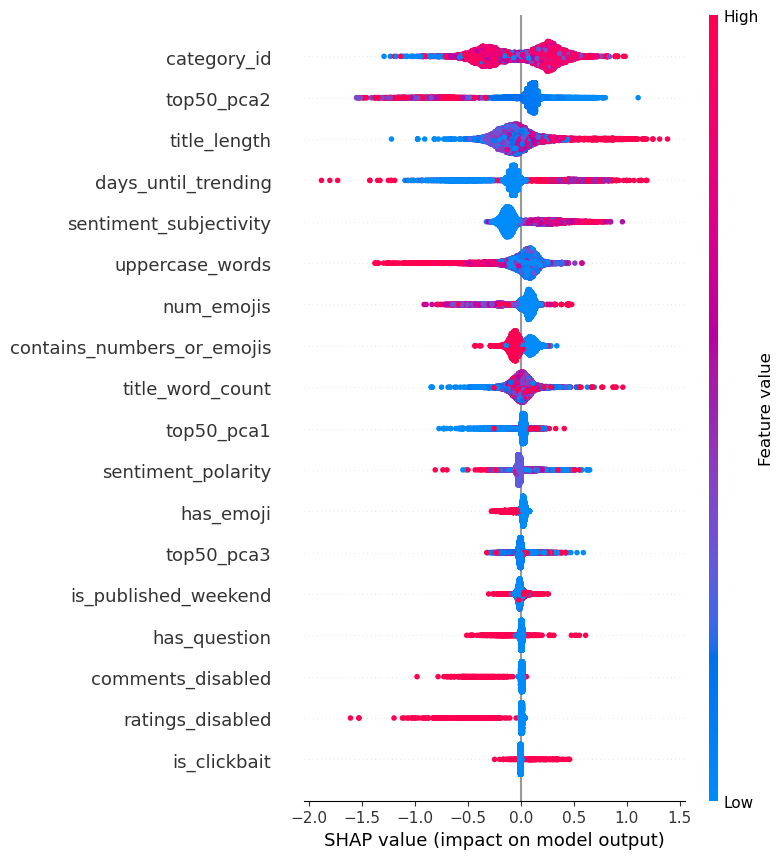

✅ SHAP summary plot saved


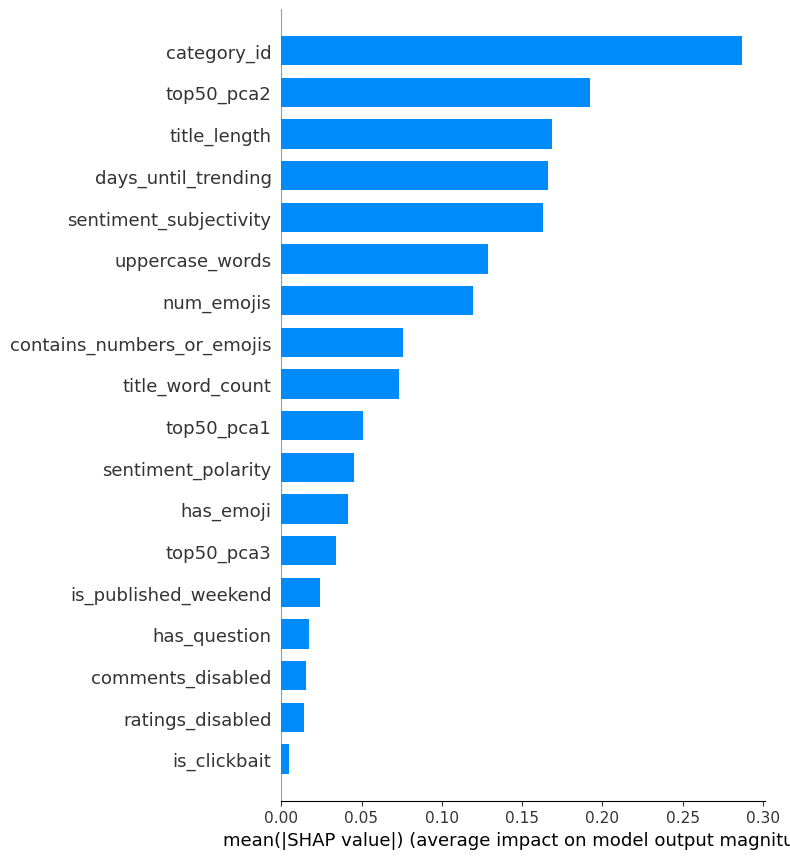

✅ SHAP importance plot saved


<Figure size 1000x600 with 0 Axes>

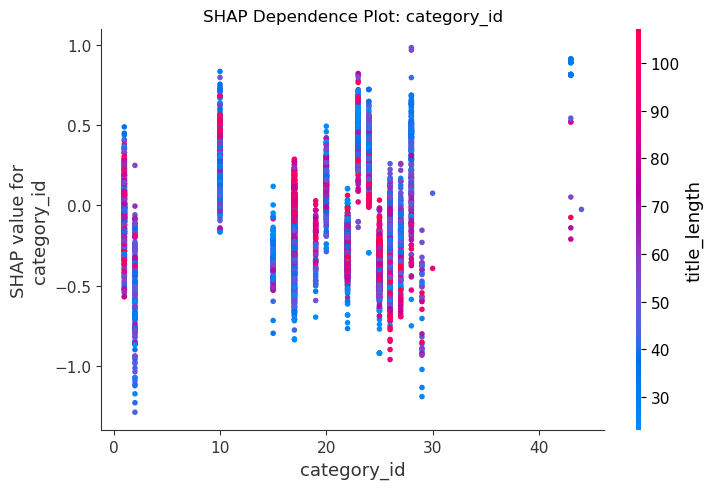

✅ SHAP dependence plot for category_id saved


In [15]:
import shap
import matplotlib.pyplot as plt
# ========================================
# SHAP ANALYSIS (for XGBoost comparison)
# ========================================

print("\n" + "="*60)
print("SHAP VALUES - XGBoost Feature Importance")
print("="*60)

# Use your trained XGBoost model
explainer = shap.TreeExplainer(best_xgb)  # Your tuned XGBoost
shap_values = explainer.shap_values(X_test)

# Plot 1: Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
plt.tight_layout()

plt.show()
print("✅ SHAP summary plot saved")

# Plot 2: Bar plot (average importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=features, 
                  plot_type="bar", show=False)
plt.tight_layout()

plt.show()
print("✅ SHAP importance plot saved")

# Plot 3: Dependence plot for top feature
top_feature_idx = np.abs(shap_values).mean(0).argmax()
top_feature = features[top_feature_idx]

plt.figure(figsize=(10, 6))
shap.dependence_plot(top_feature_idx, shap_values, X_test, 
                     feature_names=features, show=False)
plt.title(f'SHAP Dependence Plot: {top_feature}')
plt.tight_layout()
plt.show()
print(f"✅ SHAP dependence plot for {top_feature} saved")